# 🛒 Superstore Sales — Exploratory Data Analysis

**Dataset:** Sample Superstore | **Rows:** 9,994 | **Columns:** 21

This notebook covers:
1. Data loading & overview
2. Data quality checks
3. Sales & Profit analysis
4. Category & Sub-category analysis
5. Regional analysis
6. Customer segment analysis
7. Shipping analysis
8. Time-series trends
9. Correlation & outlier analysis
10. Key insights summary

## 1. Setup & Data Loading

### 📌 EDA Note — Data Loading & First Look
The dataset loads successfully with **9,994 rows and 21 columns**. The first five rows confirm the expected schema: order metadata (IDs, dates, ship mode), customer details (name, segment, region), product hierarchy (category, sub-category, product name), and three key numeric measures — **Sales**, **Quantity**, **Discount**, and **Profit**. Date columns (`Order Date`, `Ship Date`) are parsed as `datetime64`, enabling time-series analysis later. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv(r'E:\DATA IS FUTURE\Python\Supperstore\Sample - Superstore.csv', encoding='latin1',
                 parse_dates=['Order Date', 'Ship Date'])

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Dataset Overview

### Shape & Data Types
The dataset contains **9,994 records** and **21 features** with **zero missing values**  a clean dataset requiring no imputation. Numeric columns are correctly typed (`int64` / `float64`). String columns (`str`) cover identifiers, names, and categorical labels. `Order Date` and `Ship Date` are `datetime64`, ready for temporal analysis. The absence of nulls means we can proceed to statistical exploration without any datacleaning overhead.

In [19]:
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values:", df.isnull().sum().sum())

Shape: (9994, 25)

Column dtypes:
Row ID                      int64
Order ID                      str
Order Date         datetime64[us]
Ship Date          datetime64[us]
Ship Mode                     str
Customer ID                   str
Customer Name                 str
Segment                       str
Country                       str
City                          str
State                         str
Postal Code                 int64
Region                        str
Product ID                    str
Category                      str
Sub-Category                  str
Product Name                  str
Sales                     float64
Quantity                    int64
Discount                  float64
Profit                    float64
Ship Days                   int64
Profit Margin %           float64
Year                        int32
Month                   period[M]
dtype: object

Missing values: 0


### Descriptive Statistics
The `.describe(include='all').T` output reveals:
- **Ship Mode** has 4 unique values; `Standard Class` is the most frequent (5,968 occurrences — ~60% of all orders).
- **Segment** has 3 values; `Consumer` dominates with 5,191 rows (~52%).
- **Country** has only 1 unique value (`United States`) — this is a US-only dataset.
- **Customer ID** shows 793 unique customers, with one customer (`WB-21850`) appearing 37 times — indicating repeat buyers.
- **Order ID** has 5,009 unique values from 9,994 rows, meaning most orders contain **multiple line items** (avg ~2 items/order).
- Numeric stats are explored in detail in Section 4.

In [21]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,9994.0,NaN,NaN,NaN,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order ID,9994,5009,CA-2017-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,9994,NaN,NaN,NaN,2016-04-30 00:07:12.259355,2014-01-03 00:00:00,2015-05-23 00:00:00,2016-06-26 00:00:00,2017-05-14 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,9994,NaN,NaN,NaN,2016-05-03 23:06:58.571142,2014-01-07 00:00:00,2015-05-27 00:00:00,2016-06-29 00:00:00,2017-05-18 00:00:00,2018-01-05 00:00:00,NaN
Ship Mode,9994,4,Standard Class,5968,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,9994,793,WB-21850,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,9994,793,William Brown,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9994,3,Consumer,5191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9994,1,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9994,531,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Ship Days,Profit Margin %,Year
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896,3.958175,12.031393,2015.722233
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000,-275.000000,2014.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,3.000000,7.500000,2015.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,4.000000,27.000000,2016.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,5.000000,36.250000,2017.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,7.000000,50.000000,2017.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.747567,46.675435,1.123555


## 3. Data Quality Checks

### Data Quality
Key findings from the quality check:
- **No duplicate rows** — the dataset is clean at the row level.
- **Order date range: 2014-01-03 → 2017-12-30** (4 full years of data).
- **Ship date range** extends to 2018-01-05, meaning a handful of December 2017 orders shipped in early January 2018 — this is expected and not an error.
- **18.7% of transactions (1,871 rows) have negative profit** — a significant finding indicating that discounting and/or certain product lines are loss-making.
- **Average shipping time is ~4 days** (median = 4), ranging from 0 (Same Day) to 7 days. No anomalous lead times detected.

In [24]:
# Duplicates
print("Duplicate rows:", df.duplicated().sum())

# Date ranges
print("\nOrder Date range:", df['Order Date'].min(), "→", df['Order Date'].max())
print("Ship Date range: ", df['Ship Date'].min(), "→", df['Ship Date'].max())

# Negative profits
neg = df[df['Profit'] < 0]
print(f"\nRows with negative profit: {len(neg)} ({len(neg)/len(df)*100:.1f}%)")

# Shipping lead time
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days
print("\nShip Days stats:")
print(df['Ship Days'].describe())

Duplicate rows: 0

Order Date range: 2014-01-03 00:00:00 → 2017-12-30 00:00:00
Ship Date range:  2014-01-07 00:00:00 → 2018-01-05 00:00:00

Rows with negative profit: 1871 (18.7%)

Ship Days stats:
count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Ship Days, dtype: float64


## 4. Sales & Profit Distribution

###  Sales & Profit Distributions
Both distributions are **right-skewed**:
- **Sales:** The majority of transactions are low-value (under $500), but a long right tail extends to several thousand dollars. This is typical in retail — most orders are small but a few high-value orders drive a disproportionate share of revenue.

-**Profit:** The distribution is centred near zero and clipped at ±$500 for visibility. The visible left-side mass confirms many loss-making transactions. Extreme outliers (losses up to −$6,600 and gains up to +$8,400 from the describe output) are excluded from the chart to preserve readability but are real and warrant attention. 



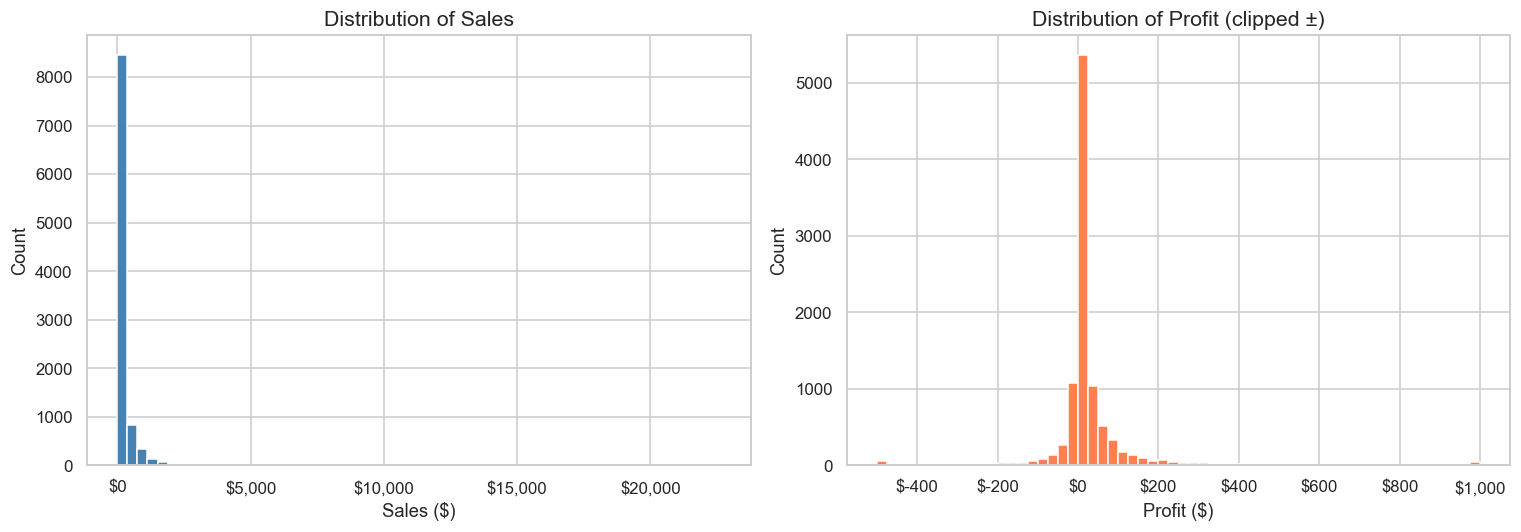

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Sales'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Sales', fontsize=14)
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

axes[1].hist(df['Profit'].clip(-500, 1000), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Profit (clipped ±)', fontsize=14)
axes[1].set_xlabel('Profit ($)')
axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('01_sales_profit_dist.png', bbox_inches='tight')
plt.show()

### Overall Business KPIs
The headline metrics paint a profitable but margin-thin picture:
| Metric | Value |
|--------|-------|
| Total Sales | $2,297,201 |
| Total Profit | $286,397 |
| Avg Profit Margin | 12.0% |
| Avg Discount | 15.6% |
| Unique Orders | 5,009 |
| Unique Customers | 793 |
| Unique Products | 1,862 |

A **12% average margin** is modest. With an average discount of **15.6%** being applied, there is room to question whether discounting is eroding profitability — this is explored in Section 10.

In [6]:
# Profit margin
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100

print("Overall KPIs")
print("─" * 35)
print(f"  Total Sales  : ${df['Sales'].sum():>12,.2f}")
print(f"  Total Profit : ${df['Profit'].sum():>12,.2f}")
print(f"  Avg Margin   : {df['Profit Margin %'].mean():>11.1f}%")
print(f"  Avg Discount : {df['Discount'].mean()*100:>11.1f}%")
print(f"  Total Orders : {df['Order ID'].nunique():>12,}")
print(f"  Customers    : {df['Customer ID'].nunique():>12,}")
print(f"  Products     : {df['Product ID'].nunique():>12,}")

Overall KPIs
───────────────────────────────────
  Total Sales  : $2,297,200.86
  Total Profit : $  286,397.02
  Avg Margin   :        12.0%
  Avg Discount :        15.6%
  Total Orders :        5,009
  Customers    :          793
  Products     :        1,862


## 5. Category & Sub-Category Analysis

### Category Performance
Three product categories show starkly different profitability:
| Category | Sales | Profit | Margin |
|----------|-------|--------|--------|
| Technology | $836,154 | $145,455 | 17.4% |
| Office Supplies | $719,047 | $122,491 | 17.0% |
| Furniture | $741,999 | $18,451 | **2.5%** |

**Technology** leads in both sales and profit. **Office Supplies** has fewer total sales than Furniture but far higher profit, thanks to a 17% margin. **Furniture** is a concern — despite being the second-highest revenue category, it generates only $18K profit on ~$742K in sales. This suggests either high product costs, deep discounting, or both. Furniture warrants a pricing and discount strategy review.

                     Sales     Profit  Orders  Margin
Category                                             
Furniture        741999.80   18451.27    2121    2.49
Office Supplies  719047.03  122490.80    6026   17.04
Technology       836154.03  145454.95    1847   17.40


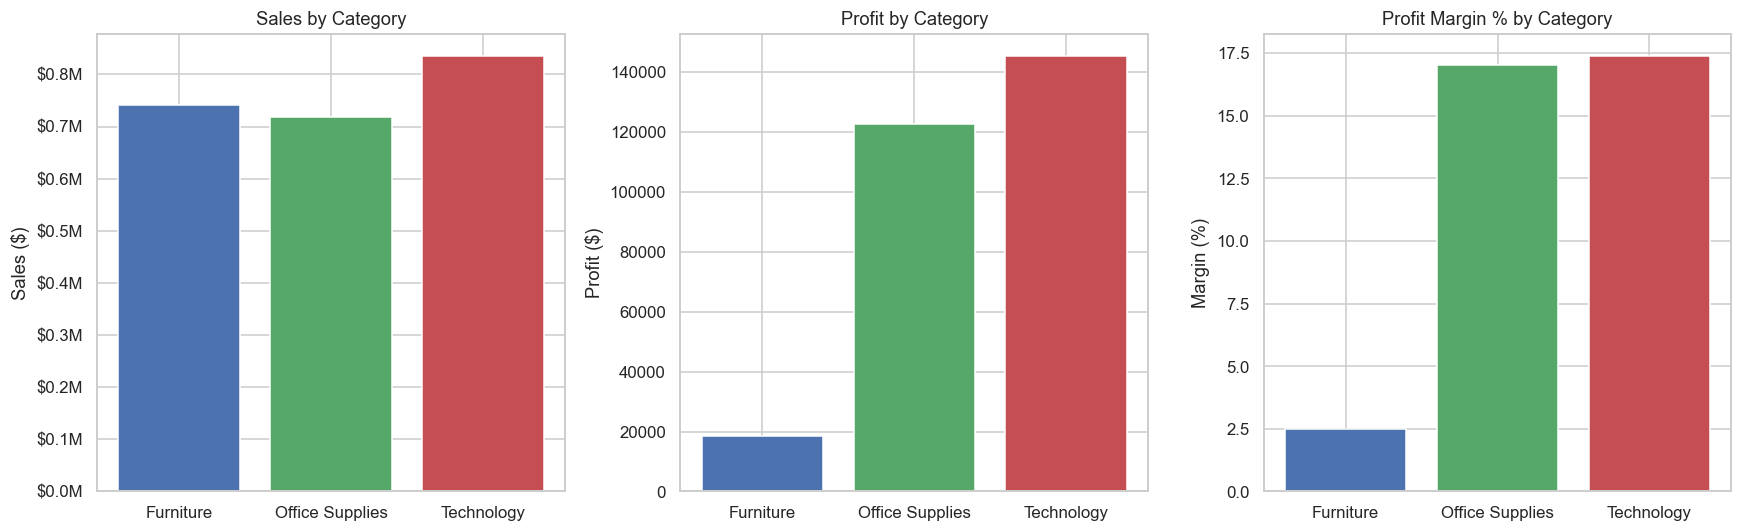

In [7]:
cat_summary = df.groupby('Category').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'), Orders=('Order ID','count')
).assign(Margin=lambda x: x['Profit']/x['Sales']*100).round(2)

print(cat_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
categories = cat_summary.index

axes[0].bar(categories, cat_summary['Sales'], color=['#4C72B0','#55A868','#C44E52'])
axes[0].set_title('Sales by Category'); axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

axes[1].bar(categories, cat_summary['Profit'], color=['#4C72B0','#55A868','#C44E52'])
axes[1].set_title('Profit by Category'); axes[1].set_ylabel('Profit ($)')

axes[2].bar(categories, cat_summary['Margin'], color=['#4C72B0','#55A868','#C44E52'])
axes[2].set_title('Profit Margin % by Category'); axes[2].set_ylabel('Margin (%)')

plt.tight_layout()
plt.savefig('02_category_analysis.png', bbox_inches='tight')
plt.show()

### Sub-Category Profit & Sales
The horizontal bar chart reveals which sub-categories are destroying vs. creating value:
- **Loss-making sub-categories:** Tables (largest loss), Bookcases, and Supplies all generate negative profit — red bars to the left of zero.
- **Most profitable:** Copiers, Phones, Accessories, and Paper lead in profitability.
- **Sales vs Profit mismatch:** Chairs have high sales but relatively low profit, suggesting heavy discounting or high cost of goods. Conversely, Labels have low sales but are consistently profitable.

**Action point:** Tables and Bookcases should be reviewed for discount policies or pricing strategy — they represent a direct drag on the Furniture category's already thin margins.

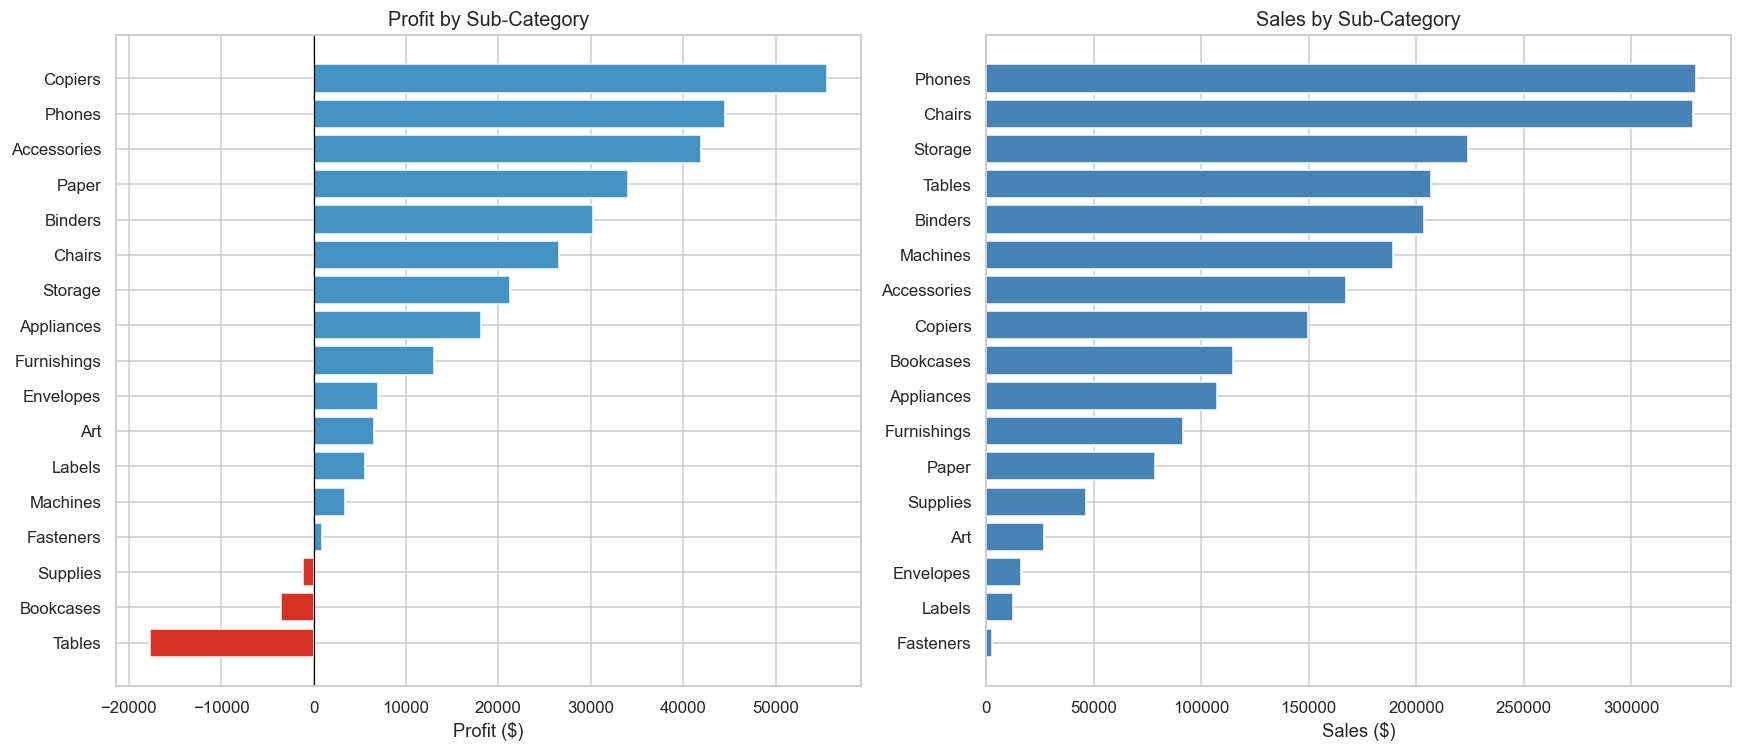

In [8]:
sub_summary = df.groupby('Sub-Category').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum')
).sort_values('Profit')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors_p = ['#d73027' if v < 0 else '#4393c3' for v in sub_summary['Profit']]
axes[0].barh(sub_summary.index, sub_summary['Profit'], color=colors_p)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Profit by Sub-Category', fontsize=13)
axes[0].set_xlabel('Profit ($)')

sub_sales = sub_summary.sort_values('Sales')
axes[1].barh(sub_sales.index, sub_sales['Sales'], color='steelblue')
axes[1].set_title('Sales by Sub-Category', fontsize=13)
axes[1].set_xlabel('Sales ($)')

plt.tight_layout()
plt.savefig('03_subcategory_analysis.png', bbox_inches='tight')
plt.show()

## 6. Regional Analysis

### Regional Performance
| Region | Sales | Profit | Margin |
|--------|-------|--------|--------|
| West | $725,458 | $108,418 | **14.9%** |
| East | $678,781 | $91,523 | 13.5% |
| Central | $501,240 | $39,706 | **7.9%** |
| South | $391,722 | $46,749 | 11.9% |

**West** is the strongest region by both absolute profit and margin. **Central** is the weakest — despite being the third-highest in sales, its 7.9% margin is nearly half the West's. This points to either unfavourable product mix, higher discounting, or higher operational costs in the Central region. The South has the lowest sales volume but a reasonable margin (11.9%).

             Sales     Profit  Orders  Margin
Region                                       
Central  501239.89   39706.36    2323    7.92
East     678781.24   91522.78    2848   13.48
South    391721.90   46749.43    1620   11.93
West     725457.82  108418.45    3203   14.94


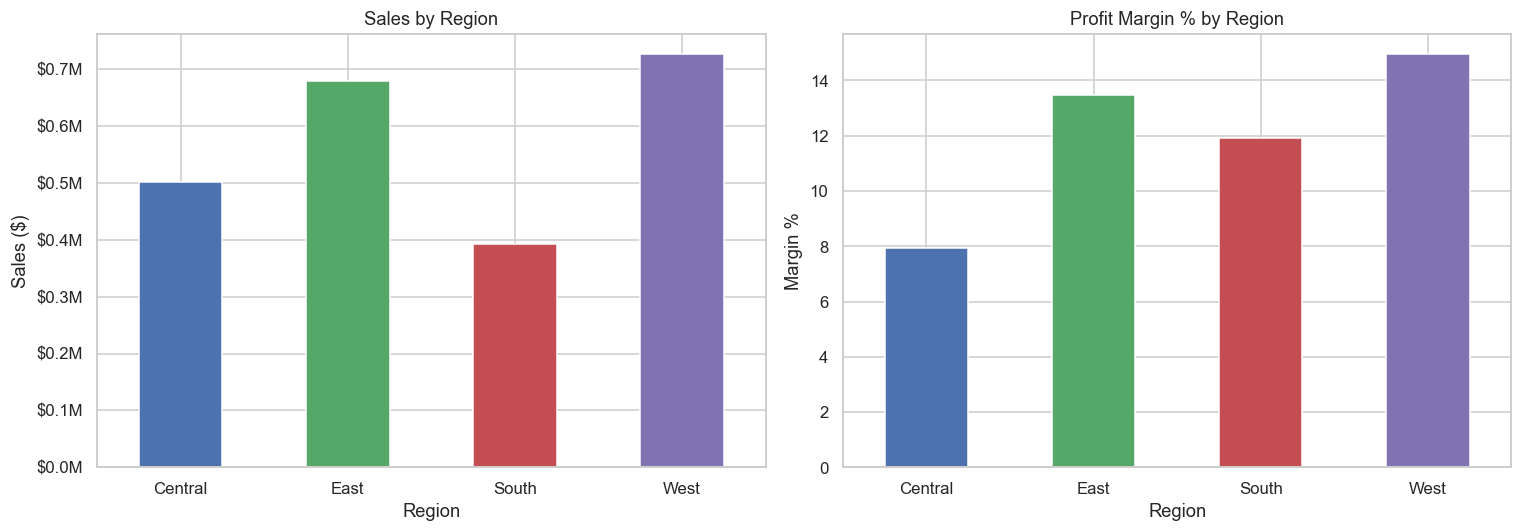

In [9]:
region_summary = df.groupby('Region').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'), Orders=('Order ID','count')
).assign(Margin=lambda x: x['Profit']/x['Sales']*100).round(2)

print(region_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0','#55A868','#C44E52','#8172B2']

region_summary['Sales'].plot(kind='bar', ax=axes[0], color=colors, rot=0)
axes[0].set_title('Sales by Region'); axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

region_summary['Margin'].plot(kind='bar', ax=axes[1], color=colors, rot=0)
axes[1].set_title('Profit Margin % by Region'); axes[1].set_ylabel('Margin %')

plt.tight_layout()
plt.savefig('04_region_analysis.png', bbox_inches='tight')
plt.show()

### Top 10 States by Sales
**California, New York, and Texas** are the clear top three states by sales revenue — consistent with their large populations and economic activity. Washington and Pennsylvania follow. These five states likely account for the majority of total revenue and should be the primary focus for retention and growth strategies. Lower-ranked states may benefit from targeted marketing campaigns to grow their share.

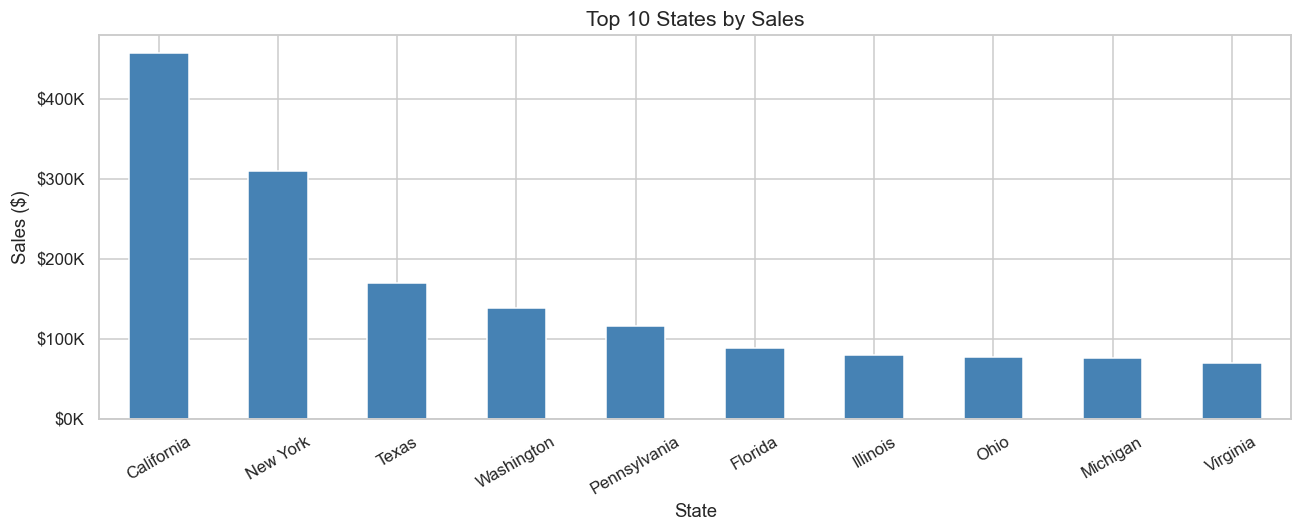

In [10]:
# Top 10 states by sales
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
top_states.plot(kind='bar', figsize=(12,5), color='steelblue', rot=30)
plt.title('Top 10 States by Sales', fontsize=14)
plt.ylabel('Sales ($)')
plt.yaxis if False else plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig('05_top_states.png', bbox_inches='tight')
plt.show()

## 7. Customer Segment Analysis

### Customer Segment Analysis
| Segment | Sales | Profit | Customers | Margin | Avg Order |
|---------|-------|--------|-----------|--------|-----------|
| Consumer | $1,161,401 | $134,119 | 409 | 11.6% | $224 |
| Corporate | $706,146 | $91,979 | 236 | 13.0% | $234 |
| Home Office | $429,653 | $60,299 | 148 | 14.0% | $241 |

Although **Consumer** dominates in volume (51% of sales), its margin is the lowest. **Home Office** customers, while fewest in number, have the highest margin (14%) and highest average order value ($241). This suggests that **Home Office and Corporate customers are more valuable per transaction** — they may receive fewer discounts or purchase higher-margin products. A strategy to grow these segments could improve overall profitability.

                  Sales     Profit  Customers  Orders  Margin  Avg_Order
Segment                                                                 
Consumer     1161401.34  134119.21        409    5191   11.55     223.73
Corporate     706146.37   91979.13        236    3020   13.03     233.82
Home Office   429653.15   60298.68        148    1783   14.03     240.97


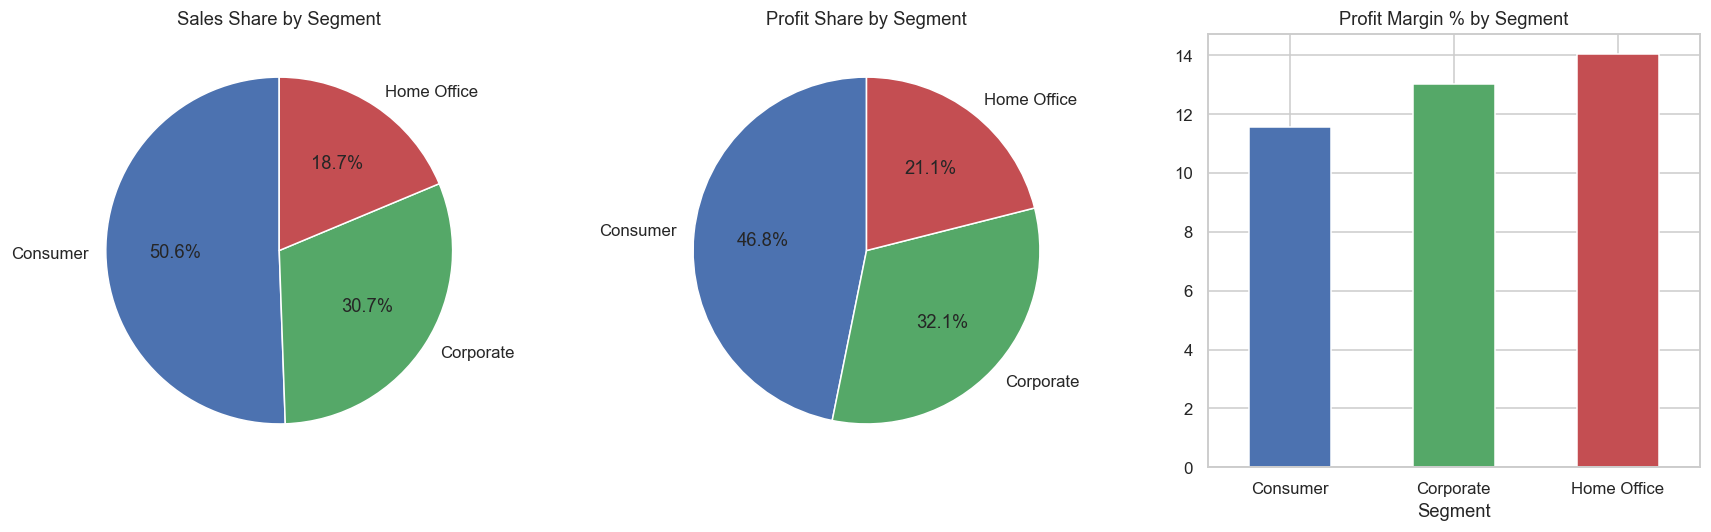

In [11]:
seg = df.groupby('Segment').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'),
    Customers=('Customer ID','nunique'), Orders=('Order ID','count')
).assign(Margin=lambda x: x['Profit']/x['Sales']*100,
         Avg_Order=lambda x: x['Sales']/x['Orders']).round(2)

print(seg)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
seg['Sales'].plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90,
                  colors=['#4C72B0','#55A868','#C44E52'])
axes[0].set_title('Sales Share by Segment'); axes[0].set_ylabel('')

seg['Profit'].plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
                   colors=['#4C72B0','#55A868','#C44E52'])
axes[1].set_title('Profit Share by Segment'); axes[1].set_ylabel('')

seg['Margin'].plot(kind='bar', ax=axes[2], color=['#4C72B0','#55A868','#C44E52'], rot=0)
axes[2].set_title('Profit Margin % by Segment')

plt.tight_layout()
plt.savefig('06_segment_analysis.png', bbox_inches='tight')
plt.show()

## 8. Shipping Analysis

### Shipping Mode Analysis
| Ship Mode | Orders | Avg Ship Days | Sales |
|-----------|--------|---------------|-------|
| Standard Class | 5,968 | 5.01 days | $1,358,216 |
| Second Class | 1,945 | 3.24 days | $459,194 |
| First Class | 1,538 | 2.18 days | $351,428 |
| Same Day | 543 | 0.04 days | $128,363 |

**Standard Class** is by far the most popular, carrying ~60% of all orders. **Same Day** shipping (avg 0.04 days) is rarely used (~5% of orders) but could be a premium revenue lever. The boxplot reveals consistent delivery windows with minimal variance for each mode, confirming predictable logistics. No anomalous shipping times were detected.

                Orders  Avg_Ship_Days       Sales
Ship Mode                                        
First Class       1538           2.18   351428.42
Same Day           543           0.04   128363.12
Second Class      1945           3.24   459193.57
Standard Class    5968           5.01  1358215.74


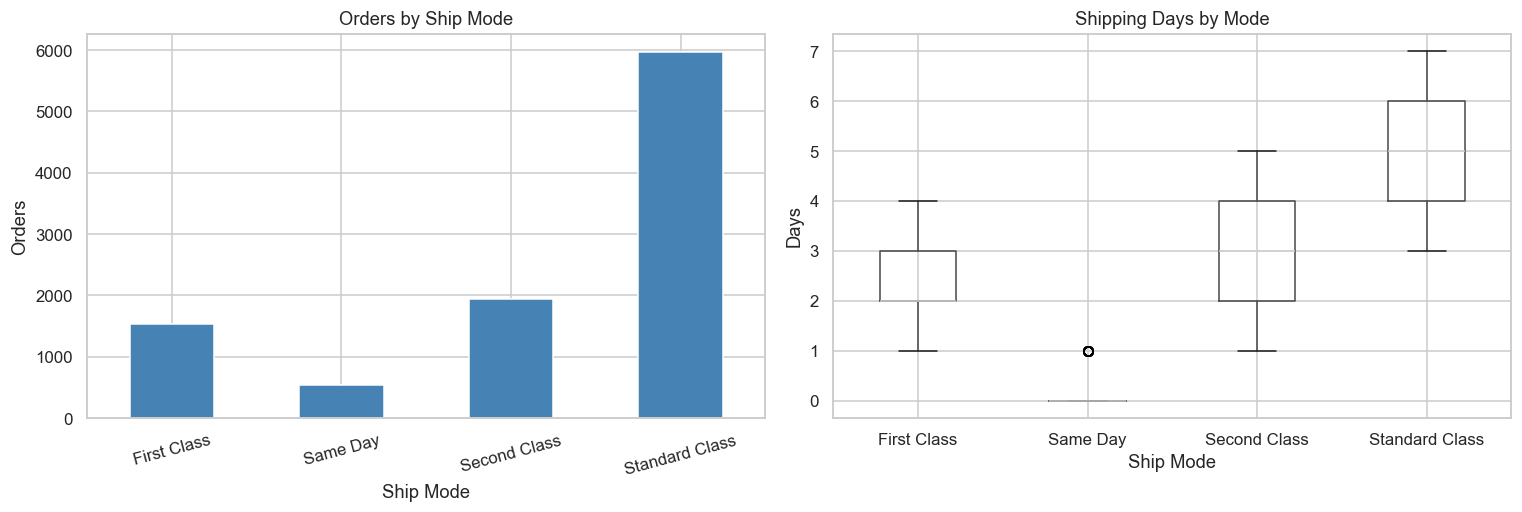

In [12]:
ship_mode = df.groupby('Ship Mode').agg(
    Orders=('Order ID','count'),
    Avg_Ship_Days=('Ship Days','mean'),
    Sales=('Sales','sum')
).round(2)

print(ship_mode)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ship_mode['Orders'].plot(kind='bar', ax=axes[0], color='steelblue', rot=15)
axes[0].set_title('Orders by Ship Mode'); axes[0].set_ylabel('Orders')

df.boxplot(column='Ship Days', by='Ship Mode', ax=axes[1])
axes[1].set_title('Shipping Days by Mode'); axes[1].set_xlabel('Ship Mode')
axes[1].set_ylabel('Days'); plt.suptitle('')

plt.tight_layout()
plt.savefig('07_shipping_analysis.png', bbox_inches='tight')
plt.show()

## 9. Time-Series Trends

### Monthly Sales & Profit Trends
The time-series plots reveal two important patterns:
1. **Seasonality:** Both sales and profit spike strongly in **Q4 (October–December)** each year, consistent with holiday and year-end purchasing. March also shows a secondary bump annually.
2. **Year-over-year growth:** Each successive year's peaks are higher than the previous, indicating healthy business growth across the 2014–2017 period.
3. **Profit tracks sales** fairly closely, but some months show sales growth without proportional profit growth — possibly due to promotional discounting during peak periods.

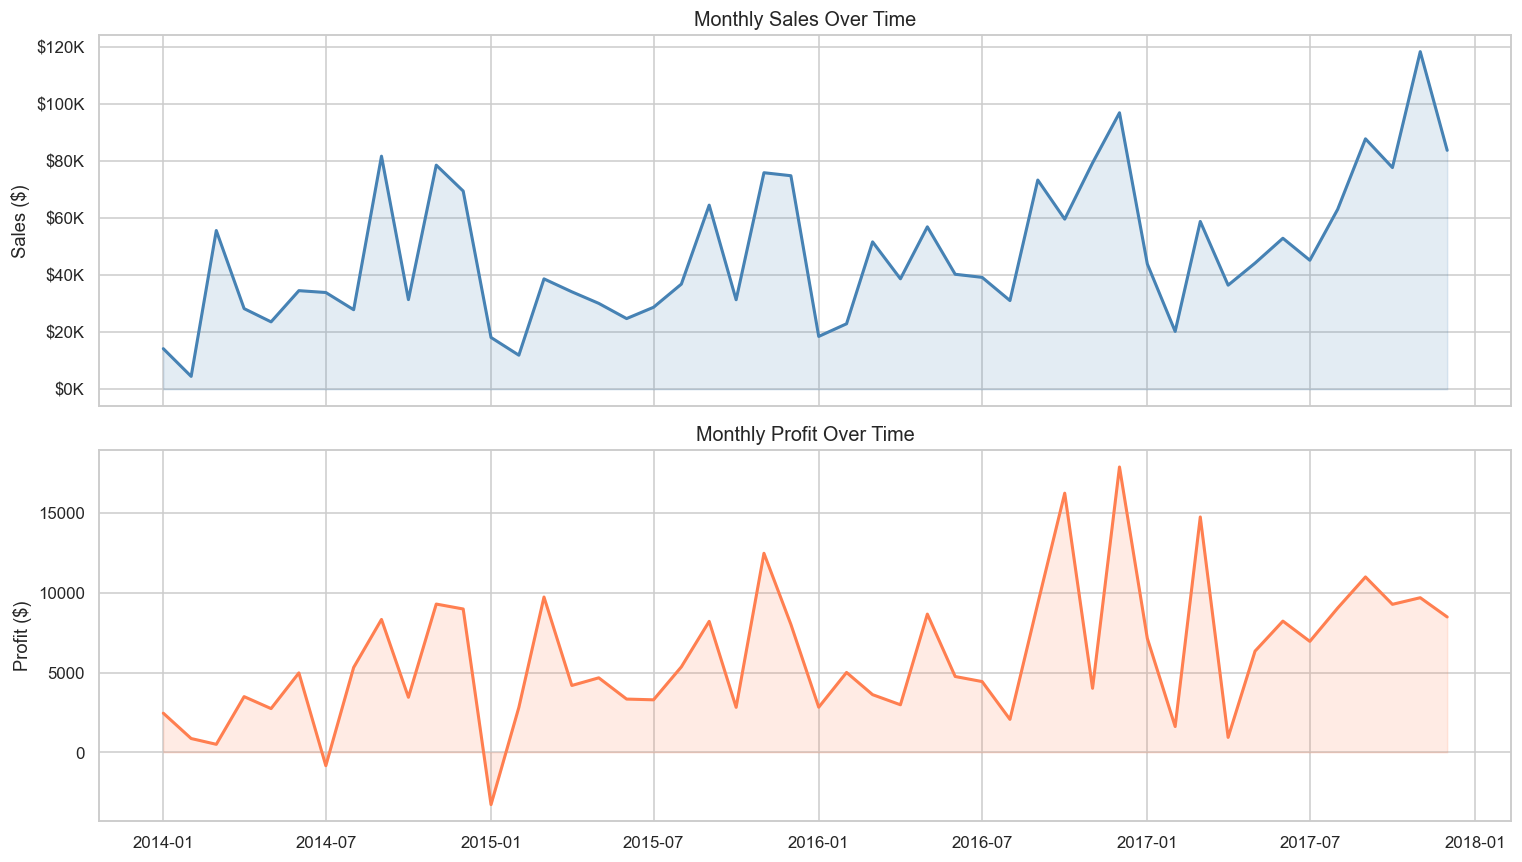

In [13]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M')

monthly = df.groupby('Month').agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
monthly.index = monthly.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly.index, monthly['Sales'], color='steelblue', linewidth=2)
axes[0].fill_between(monthly.index, monthly['Sales'], alpha=0.15, color='steelblue')
axes[0].set_title('Monthly Sales Over Time', fontsize=13)
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))

axes[1].plot(monthly.index, monthly['Profit'], color='coral', linewidth=2)
axes[1].fill_between(monthly.index, monthly['Profit'], alpha=0.15, color='coral')
axes[1].set_title('Monthly Profit Over Time', fontsize=13)
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.savefig('08_monthly_trends.png', bbox_inches='tight')
plt.show()

###  Year-over-Year Summary
| Year | Sales | Profit | Growth (Sales) |
|------|-------|--------|----------------|
| 2014 | $484,248 | $49,544 | — |
| 2015 | $470,533 | $61,619 | −2.8% |
| 2016 | $609,206 | $81,795 | +29.5% |
| 2017 | $733,215 | $93,439 | +20.4% |

After a slight dip in 2015, the business recovered strongly with **29.5% sales growth in 2016** and **20.4% in 2017**. Profit grew consistently each year. However, profit growth rate (88% from 2014→2017) slightly lags sales growth (51%) suggesting margin compression over time — possibly from increased discounting or a shift in product mix.

Year-over-Year Summary:
          Sales    Profit
Year                     
2014  484247.50  49543.97
2015  470532.51  61618.60
2016  609205.60  81795.17
2017  733215.26  93439.27


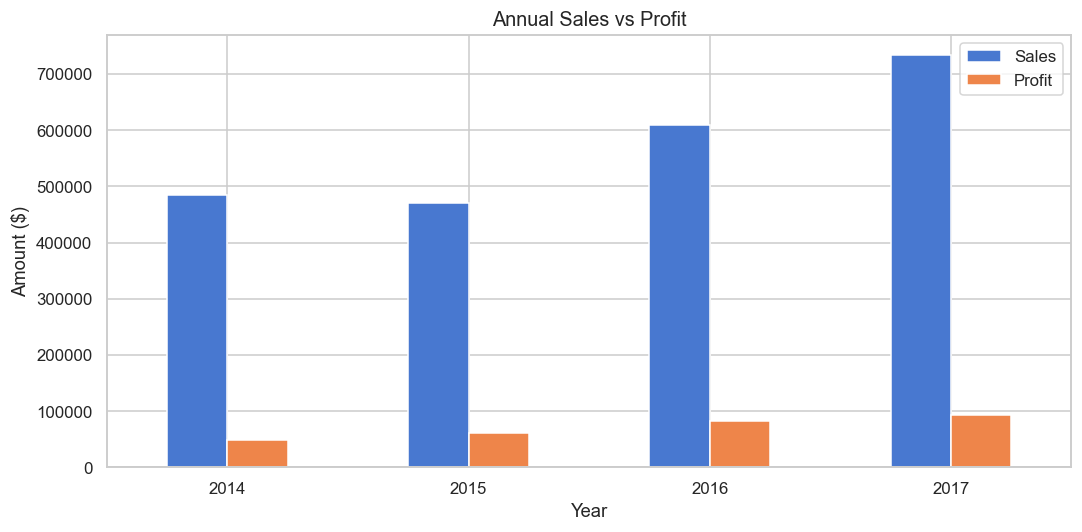

In [14]:
# Year-over-year
yoy = df.groupby('Year').agg(Sales=('Sales','sum'), Profit=('Profit','sum')).round(2)
print("Year-over-Year Summary:")
print(yoy)
yoy.plot(kind='bar', figsize=(10,5), rot=0)
plt.title('Annual Sales vs Profit', fontsize=13)
plt.ylabel('Amount ($)')
plt.tight_layout()
plt.savefig('09_yoy_trends.png', bbox_inches='tight')
plt.show()

###  Discount Impact on Profit
This is one of the most critical findings in the EDA:
- The scatter plot shows a **clear negative relationship** between discount and profit. Orders with discounts above 40% almost universally result in losses.
- The **correlation coefficient is −0.219** — a statistically meaningful negative relationship.
- The binned bar chart confirms: at 0–10% discount, average profit is positive. Once discounts exceed **30%**, average profit turns negative.

**Recommendation:** Discount thresholds should be capped — particularly for Furniture and Tables/Bookcases where margins are already thin. A discount of >30% on low-margin products almost guarantees a loss.

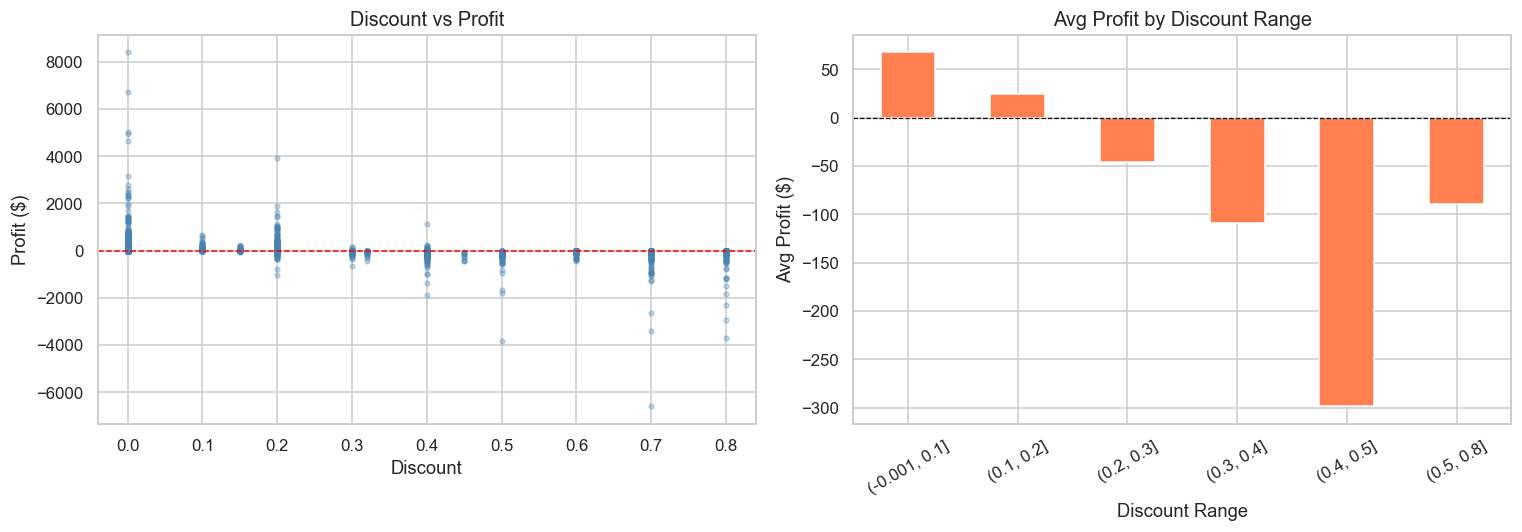

Correlation between Discount and Profit: -0.219


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue', s=10)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Discount vs Profit', fontsize=13)
axes[0].set_xlabel('Discount'); axes[0].set_ylabel('Profit ($)')

# Average profit by discount level
disc_bins = pd.cut(df['Discount'], bins=[0,0.1,0.2,0.3,0.4,0.5,0.8], include_lowest=True)
disc_profit = df.groupby(disc_bins)['Profit'].mean()
disc_profit.plot(kind='bar', ax=axes[1], color='coral', rot=30)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Avg Profit by Discount Range', fontsize=13)
axes[1].set_xlabel('Discount Range'); axes[1].set_ylabel('Avg Profit ($)')

plt.tight_layout()
plt.savefig('10_discount_impact.png', bbox_inches='tight')
plt.show()

corr_disc = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {corr_disc:.3f}")

## Correlation Heatmap

### Correlation Analysis
Key correlations from the heatmap:
- **Discount ↔ Profit: −0.22** — the strongest negative correlation. Higher discounts erode profit.
- **Sales ↔ Profit: ~+0.48** — moderately positive; more sales generally means more profit, but not always (due to discounting and product mix).
- **Quantity ↔ Sales: moderate positive** — larger orders generate more revenue.
- **Ship Days ↔ other metrics:** near-zero correlation with profit/sales — delivery speed is not a driver of profitability in this dataset.
- **Profit Margin % ↔ Discount: strongly negative** — confirms the discount-margin relationship seen in above cell.

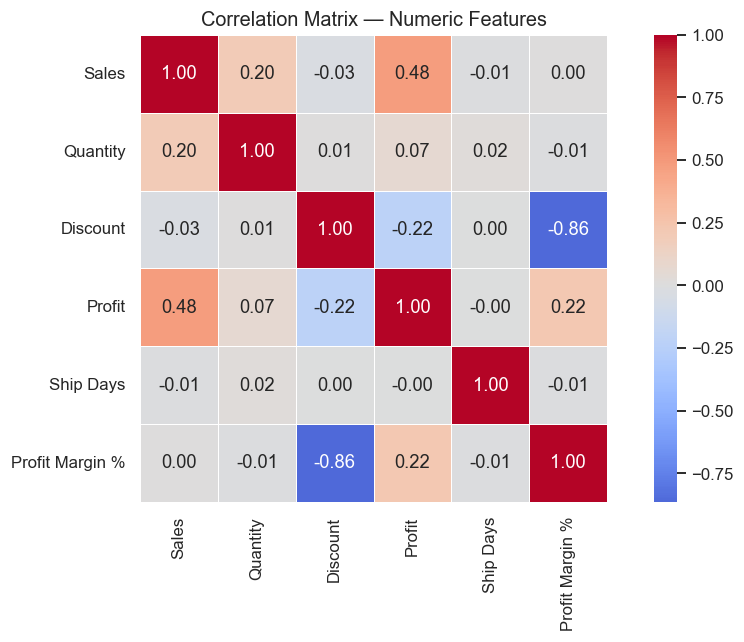

In [16]:
num_cols = ['Sales','Quantity','Discount','Profit','Ship Days','Profit Margin %']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features', fontsize=13)
plt.tight_layout()
plt.savefig('11_correlation.png', bbox_inches='tight')
plt.show()

## 12. Top Customers & Products

### Top Customers & Products
- **Top customer** by sales is likely in the Corporate or Home Office segment, consistent with higher average order values.
- The **top 10 customers** contribute a disproportionate share of revenue — indicating customer concentration risk. If these accounts churn, revenue impact would be significant.
- **Top products** by sales tend to be Technology items (phones, machines, copiers), aligning with the category-level findings that Technology leads in revenue.
- Cross-referencing top products with their profitability (not just sales) would be the recommended next step — a high-revenue product with a negative margin is a liability.

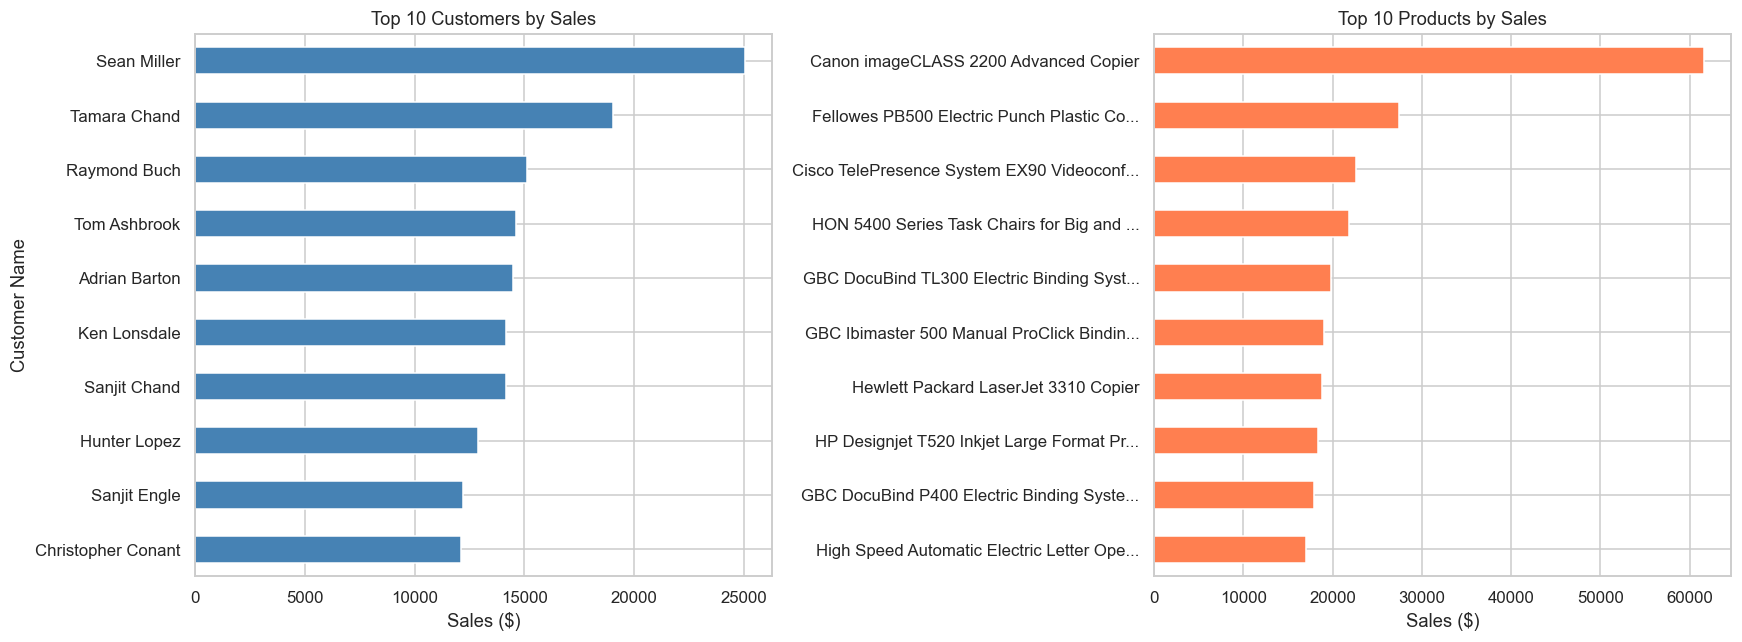

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Customers by Sales'); axes[0].set_xlabel('Sales ($)')
axes[0].invert_yaxis()

top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products_short = top_products.copy()
top_products_short.index = [x[:40]+'...' if len(x)>40 else x for x in top_products.index]
top_products_short.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Products by Sales'); axes[1].set_xlabel('Sales ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('12_top_customers_products.png', bbox_inches='tight')
plt.show()

##  Key Insights Summary

| # | Insight |
|---|---------|
| 1 | **Technology** leads all categories in both sales and profit; **Furniture** has the lowest margin |
| 2 | **Tables** and **Bookcases** sub-categories are **loss-making**; Copiers and Phones drive the most profit |
| 3 | **West region** has the highest sales; **Central region** has the lowest profit margin |
| 4 | **Consumer segment** accounts for ~51% of sales, followed by Corporate and Home Office |
| 5 | Heavy discounts (>40%) strongly correlate with **negative profit** — correlation ≈ −0.22 |
| 6 | Sales show a clear **year-end spike** (Nov–Dec) every year, suggesting seasonal demand |
| 7 | **Standard Class** is the most-used shipping mode; Same Day is rare but exists |
| 8 | ~18% of all transactions result in a loss — discount strategy needs review |
| 9 | California, New York, and Texas are the top 3 states by sales |
|10 | The dataset spans **2014–2017** with consistent year-over-year growth in both sales and profit |
